In [3]:
using CMPSExcitations

In [69]:
# canonical basis
function projection_matrix(D, M)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E / sqrt(2) - M * Diagonal(F) / M
        W2 = E / sqrt(2) + M * Diagonal(F) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return P
end

# canonical basis
function excitation_matrix(Heff, D)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function excitation_matrix_constrained(Heff, M)
    D = size(M, 1) # R = MDᵣ/M
    H = excitation_matrix(Heff, D)
    P = projection_matrix(D, M)

    P' * H * P, P
end

function leftcanonical(state, cmps=false)
    leftgauge!(state)
    r = rightenv(state)[1][]
    D, U = eigen(r)
    Q = U \ state.Q[] * U
    R = U \ state.Rs[1][] * U
    return (cmps) ? InfiniteCMPS(Constant(Q), (Constant(R), Constant(R))) : (Q, R)
end

leftcanonical (generic function with 2 methods)

In [114]:
Hsingle(c, μ) = ∫(2 * ∂ψ̂' * ∂ψ̂ - 2 * μ * ψ̂' * ψ̂ + 4 * c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
# Hcoupled(c, μ) = ∫(
#     (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
#      ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
#      2 * c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁), (-Inf, +Inf));

# why does this work better???
# Hcoupled(c, μ) = ∫(
#     (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
#      ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
#      c * (ψ̂₂') * (ψ̂₁') * ψ̂₂ * ψ̂₁ + c * (ψ̂₂') * (ψ̂₁') * ψ̂₁ * ψ̂₂), (-Inf, +Inf));
Hcoupled(c, μ) = ∫(
    (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
     ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
     c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁ + c * (ψ̂₂') * (ψ̂₁') * ψ̂₁ * ψ̂₂), (-Inf, +Inf));

In [154]:
c, μ = 10., 5.
tol = 1e-10
HLL = Hsingle(c, μ)

Ds = [2]
stateLL = find_groundstate(Ds, HLL, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
D = maximum(Ds)
println("Energy density: ", expval(HLL.h, stateLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateLL)[], "\n Order parameter: ", expval(ψ̂, stateLL)[])
println("-------------------------------------")
stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1], stateLL.Rs[1]));
leftgauge!(stateCLL)
HCLL = Hcoupled(c, μ)
println("Energy density: ", expval(HCLL.h, stateCLL)[], "\nParticle density: ", expval(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, stateCLL)[], "\nDensity imbalance: ", expval(ψ̂₁' * ψ̂₁ - ψ̂₂' * ψ̂₂, stateCLL)[])
println("-------------------------------------")

Optimizing D=2
D = 2 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
  0.003758 seconds (26.52 k allocations: 1.034 MiB)
---------------
Energy density: -2.555100535380943
 Particle density: 0.4059871156641031
 Order parameter: 0.5119596774276124
-------------------------------------
Energy density: -2.5551005353809466
Particle density: 0.811974231328207
Density imbalance: 0.0
-------------------------------------


┌ Info: YangGaudinCMPS ground state: initialization with e = 24.146027234485
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:106
┌ Info: LBFGS: converged after 20 iterations: f = -2.555100535381, ‖∇f‖ = 2.0471e-12
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138
┌ Info: YangGaudinCMPS ground state: converged after 21 iterations: e = -2.555100535381, ‖∇e‖ = 2.0471e-12
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118


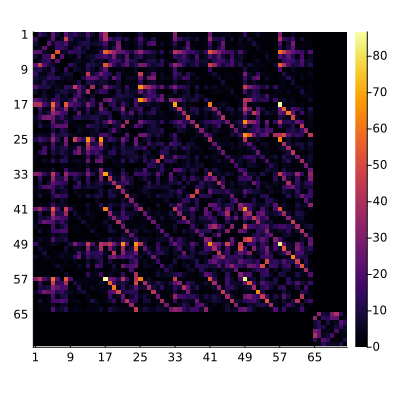

In [160]:
# stateCLL = leftcanonical(stateCLL, true)
_, M = eigen(stateLL.Rs[1][]);
P = projection_matrix(D, M)

Q = P[1:D^2, D^2+1:end]
Qn = Matrix(qr(Q).Q)
Pn = copy(P)
Pn[1:D^2, D^2+1:end] .= Qn / sqrt(2)
Pn[D^2+1:end, D^2+1:end] .= -Qn / sqrt(2)
Pn = Matrix(qr(P).Q);

space = InfiniteCMPSExcitationSpace(0, stateCLL, stateCLL)
Heff = excitation_matrix(excitation_operator(HCLL, space), D);
res = round.(Pn' * Heff * Pn, digits=1)
heatmap(abs.(res .- Diagonal(res)), yflip=true, aspect_ratio=1, size=(400, 400), xticks=1:D:D^2+D, yticks=1:D:D^2+D)

### Explicitly constructing goldstone modes

In [156]:
# canonical basis
function projection_matrix(D, M)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E
        W2 = E + M * Diagonal(F) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return Matrix(qr(P).Q) # moves to an orthogonal projection
end

# canonical basis
function excitation_matrix(Heff, D)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function excitation_matrix_constrained(Heff, M)
    D = size(M, 1) # R = MDᵣ/M
    H = excitation_matrix(Heff, D)
    P = projection_matrix(D, M)

    P' * H * P, P
end

excitation_matrix_constrained (generic function with 1 method)

In [157]:
Hsingle_ll(c, μ) = ∫(∂ψ̂' * ∂ψ̂ - μ * ψ̂' * ψ̂ + c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
c, μ = 10., 5.
tol = 1e-10
Ds = [4, 8]
D = maximum(Ds)

HLL = Hsingle(c, μ)
stateLL = find_groundstate(Ds, HLL, InfiniteCMPS, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
println("Energy density: ", expval(HLL.h, stateLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateLL)[], "\n Order parameter: ", expval(ψ̂, stateLL)[])

HCLL = Hcoupled(c, μ)
stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1], stateLL.Rs[1]));
println("Energy density: ", expval(HCLL.h, stateCLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateCLL)[], "\n Order parameter: ", expval(ψ̂, stateCLL)[])

Optimizing D=4


┌ Info: UniformCMPS ground state: initialization with e = 399.651522213137
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:115
┌ Info: LBFGS: converged after 115 iterations: f = -5.050019379406, ‖∇f‖ = 2.8321e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 4 | InfiniteCMPS{Constant{Matrix{Float64}}, 1}
  3.030006 seconds (11.33 M allocations: 573.945 MiB, 2.31% gc time, 97.26% compilation time)
---------------
Optimizing D=8


┌ Info: UniformCMPS ground state: converged after 116 iterations: e = -5.050019379406, ‖∇e‖ = 2.8321e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:127
┌ Info: UniformCMPS ground state: initialization with e = -5.050019379116
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:115
┌ Info: LBFGS: converged after 403 iterations: f = -5.101997460806, ‖∇f‖ = 6.3670e-11
└ @ OptimKit /home/ashankar/.julia/packages/OptimKit/xpmbV/src/lbfgs.jl:138


D = 8 | InfiniteCMPS{Constant{Matrix{Float64}}, 1}
  3.349266 seconds (5.40 M allocations: 432.343 MiB, 2.77% gc time, 7.31% compilation time)
---------------
Energy density: 

┌ Info: UniformCMPS ground state: converged after 404 iterations: e = -5.101997460806, ‖∇e‖ = 6.3670e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:127


-5.101997460806294
 Particle density: 0.7850064187778261
 Order parameter: 0.4309827953232967
Energy density: -2.655241675469525
 Particle density: 0.4013375137259472
 Order parameter: 0.30925647287648345


In [163]:
leftgauge!(stateCLL)
Q, R = stateCLL.Q[], stateCLL.Rs[1][];
W1, W2 = R, -R;

function leftgaugetv(Q, R, V, W1, W2, p)
    # assuming Q, R are in cMPS left gauge
    X, _ = linsolve(-R' * (W1 + W2) - V) do X
        (Q * X - X * Q) + 1im * p * X + 2 * R' * (R * X - X * R)
    end

    return V + (Q * X - X * Q) + 1im * p * X, W1 + (R * X - X * R), W2 + (R * X - X * R)
end

ps = range(0, 5., 20)
energies = zeros(ComplexF64, length(ps))
ρr = rightenv(stateCLL)[1][]

Threads.@threads for idx in eachindex(ps)
    V, W1, W2 = leftgaugetv(Q, R, zero(Q), R, -R, ps[idx])
    # ∫⟨H⟩ - ⟨H₀⟩ = E -> intensive contribution to energy on top of extensive ground state energy
    space = InfiniteCMPSExcitationSpace(ps[idx], stateCLL, stateCLL)
    Heff, P = excitation_matrix_constrained(excitation_operator(HCLL, space), eigen(R).vectors)

    # Heff maps between D^2 + D subspace; so P * Heff * P' maps between 2D^2 space while keeping the multispecies constraint satisfied
    Ws = P * Heff * P' * vcat(vec(W1), vec(W2))

    HW1 = reshape(view(Ws, 1:D^2), D, D)
    HW2 = reshape(view(Ws, (D^2+1):2*D^2), D, D)

    ρr = I
    energies[idx] = tr(HW1 * ρr * W1' + HW2 * ρr * W2')
end

energies

20-element Vector{ComplexF64}:
  1920.069781998239 - 9.195773158874124e-15im
  1921.814013825803 - 1.1712852909795402e-13im
    1927.0467093085 + 8.215650382226158e-15im
 1935.7678684463274 - 1.8429702208777599e-13im
 1947.9774912392857 + 1.4210854715202004e-14im
  1963.675577687376 + 6.084022174945858e-14im
 1982.8621277905952 + 2.3092638912203256e-14im
  2005.537141548948 + 1.8118839761882555e-13im
 2031.7006189624292 - 7.993605777301127e-14im
  2061.352560031044 - 7.194245199571014e-14im
 2094.4929647547897 + 9.50350909079134e-14im
  2131.121833133662 - 1.176836406102666e-13im
 2171.2391651676694 - 1.270095140171179e-13im
  2214.844960856807 - 1.652011860642233e-13im
  2261.939220201076 - 1.0125233984581428e-13im
  2312.521943200475 + 7.904787935331115e-14im
  2366.593129855007 - 6.039613253960852e-14im
 2424.1527801646675 - 3.268496584496461e-13im
 2485.2008941294594 - 4.3787196091216174e-13im
 2549.7374717493817 - 2.682298827494378e-13im

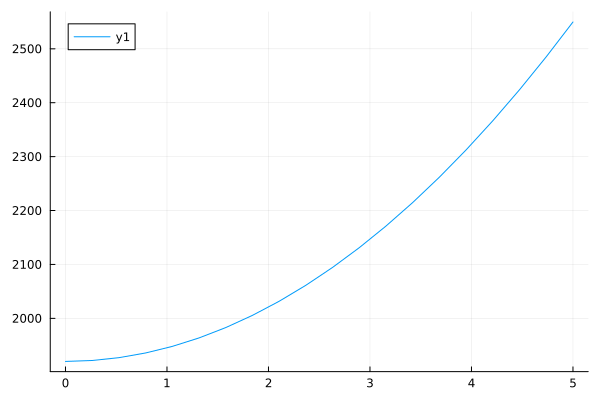

In [164]:
plot(ps, real.(energies))